In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/dup1_600.csv
/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/test1.csv
/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/dup1_1380_new.csv
/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/train1.csv
/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/train_up_removed_weird.csv
/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/dup1_600_new.csv
/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/train_without_up_cleaned_1889.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/train1.csv', dtype={
 'HighBP': 'int',
 'HighChol': 'int',
 'CholCheck': 'int',
 'Smoker': 'int',
 'Stroke': 'int',
 'HeartDiseaseorAttack': 'int',
 'PhysActivity': 'int',
 'Fruits': 'int',
 'Veggies': 'int',
 'HvyAlcoholConsump': 'int',
 'AnyHealthcare': 'int',
 'NoDocbcCost':'int',
 'DiffWalk': 'int',
 'Sex': 'int'
 })
df
# sns.pairplot(data = df)
#display(df['BMI'].describe())
df = df[df.duplicated() == False]
#df.duplicated().sum()
#df.head()
#df.shape

In [4]:

df2 = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/test1.csv', dtype={
 'HighBP': 'int',
 'HighChol': 'int',
 'CholCheck': 'int',
 'Smoker': 'int',
 'Stroke': 'int',
 'HeartDiseaseorAttack': 'int',
 'PhysActivity': 'int',
 'Fruits': 'int',
 'Veggies': 'int',
 'HvyAlcoholConsump': 'int',
 'AnyHealthcare': 'int',
 'NoDocbcCost':'int',
 'DiffWalk': 'int',
 'Sex': 'int'
 })

test_data_id = df2['row_id']
df2 = df2.drop(columns=['row_id'])

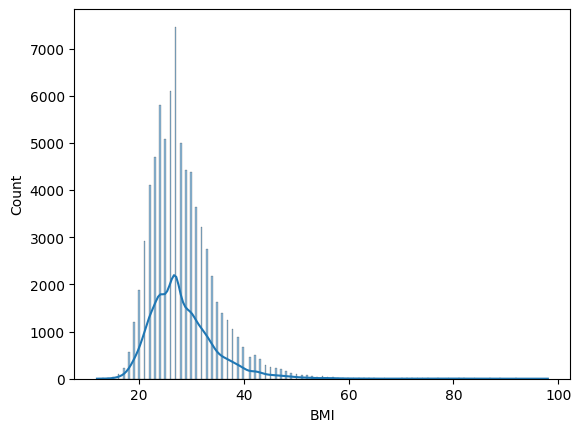

In [5]:
sns.histplot(data = df2, x = 'BMI', kde = True)
df = df[(df['BMI'] >= 12) & (df['BMI'] <= 95) ]

In [6]:
df['MentHlth'] = df['MentHlth']/30
df['PhysHlth'] = df['PhysHlth']/30
df['Income'] = (df['Income']-1)/(7)
df['Age'] = (df['Age']-1)/(12)
df['Education'] = (df['Education']-1)/(5)
df['GenHlth'] = (df['GenHlth'] -1)/4

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['BMI'] = scaler.fit_transform(df[['BMI']])
display(df.describe())
df2['MentHlth'] = df2['MentHlth']/30
df2['PhysHlth'] = df2['PhysHlth']/30
df2['Income'] = (df2['Income']-1)/(7)
df2['Age'] = (df2['Age']-1)/(12)
df2['Education'] = (df2['Education']-1)/(5)
df2['GenHlth'] = (df2['GenHlth'] -1)/4

df2['BMI'] = scaler.transform(df2[['BMI']])
display(df2.describe())


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,162697.000000,162697.000000,162697.000000,1.626970e+05,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,...,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000
mean,0.448109,0.437642,0.959858,9.519352e-16,0.460340,0.043234,0.101114,0.740204,0.618198,0.799652,...,0.091016,0.394536,0.126485,0.163128,0.180304,0.441170,0.589199,0.799495,0.704531,0.187944
std,0.497302,0.496098,0.196293,1.000003e+00,0.498426,0.203383,0.301481,0.438524,0.485830,0.400262,...,0.287632,0.266256,0.274595,0.313193,0.384442,0.496528,0.256857,0.198197,0.298360,0.390669
min,0.000000,0.000000,0.000000,-2.119075e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,-6.402548e-01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.416667,0.600000,0.571429,0.000000
50%,0.000000,0.000000,1.000000,-2.705497e-01,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.583333,0.800000,0.714286,0.000000
75%,1.000000,1.000000,1.000000,3.456254e-01,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.500000,0.066667,0.133333,0.000000,1.000000,0.750000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,8.109432e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,...,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000
mean,0.428821,0.423736,0.963340,-0.098449,0.443209,0.041194,0.093609,0.755098,0.633055,0.811022,...,0.951461,0.083268,0.377697,0.105505,0.141286,0.169019,0.437178,0.586097,0.810399,0.722095
std,0.494911,0.494153,0.187928,0.814661,0.496768,0.198739,0.291286,0.430032,0.481975,0.391494,...,0.214903,0.276288,0.267062,0.245983,0.290483,0.374771,0.496041,0.255269,0.196960,0.295164
min,0.000000,0.000000,0.000000,-2.119075,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,-0.640255,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.416667,0.600000,0.571429
50%,0.000000,0.000000,1.000000,-0.270550,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.583333,0.800000,0.857143
75%,1.000000,1.000000,1.000000,0.222390,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.500000,0.066667,0.100000,0.000000,1.000000,0.750000,1.000000,1.000000
max,1.000000,1.000000,1.000000,8.479137,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


# X_train = df.drop('Diabetes_binary', axis=1)
# X_test = df2.copy()
# y_train = df['Diabetes_binary']
# y_train = pd.get_dummies(y_train, dtype = int).values

callback = EarlyStopping(
    monitor = 'val_macro_f1',
    min_delta = 0.00001,
    patience = 20,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights = True
)

In [8]:
pip install -U imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: sklearn-compat
    Found existing installation: sklearn-compat 0.1.5
    Uninstalling sklearn-compat-0.1.5:
      Successfully uninstalled sklearn-compat-0.1.5
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.1
    Uninstalling imbalanced-learn-0.14.1:
      Successfully uninstalled imbalanced-learn-0.14.1
Note: you may need to restart the kernel to use updated packages.


In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
df = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/data-diabetes/train_without_up_cleaned_1889.csv')
df = df.sort_values(by = 'row_id')
df.set_index('row_id', inplace = True)
df = df.reset_index()
df = df.drop(columns = 'row_id')
df

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, stratify = df['Diabetes_binary'], random_state=42)

X_train = train_df.drop('Diabetes_binary', axis=1)
y_train = train_df['Diabetes_binary']

smote = SMOTE(sampling_strategy ='minority', random_state = 42)
X_train, y_train = smote.fit_resample(X_train, y_train)
y_train.value_counts()
y_train = pd.get_dummies(y_train, dtype = int).values


In [11]:
# df_0 = train_df[train_df['Diabetes_binary'] == 0]
# df_1 = train_df[train_df['Diabetes_binary'] == 1]

# df_1 = df_1.sample(len(df_0), replace = True, random_state = 42)

# train_df = pd.concat([df_0, df_1])
# train_df = train_df.sample(frac= 1, random_state = 42)
# train_df['row_id'] = train_df.index
# train_df.to_csv('train_NN_0p6.csv', index = False)
# train_df = train_df.drop(columns = ['row_id'])

# X_train = train_df.drop('Diabetes_binary', axis=1)
# y_train = train_df['Diabetes_binary']
# y_train = pd.get_dummies(y_train, dtype = int).values

X_test = val_df.drop('Diabetes_binary', axis=1)
y_test = val_df['Diabetes_binary']
y_test = pd.get_dummies(y_test, dtype = int).values

In [12]:
pip install -U keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [13]:
import keras_tuner as kt

In [14]:
def build_model(hp):
    model = keras.Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dropout(hp.Choice('dp0', values = [0.1, 0.2, 0.3,0.4,0.5,0.6])))

    for i in range(hp.Int('num_layers', 1, 20)):
        model.add(Dense(units=hp.Int('unit' + str(i),
                                      min_value=2,
                                      max_value=512,
                                      step=8),
                                      activation='relu'))
        model.add(Dropout(hp.Choice('dp' + str(i), values = [0.1, 0.2, 0.3,0.4,0.5,0.6])))


    model.add(Dense(2, activation='softmax'))
    optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd', 'adadelta'])

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy', keras.metrics.F1Score(average='macro', name = 'macro_f1')])
    return model


tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective('val_macro_f1', direction = 'max'),
    max_trials=15,
    directory='my_dir',
    project_name='my_project'
)

tuner.search(X_train, y_train, epochs=5, validation_data = (X_test, y_test))

Trial 15 Complete [00h 02m 01s]
val_macro_f1: 0.6102334260940552

Best val_macro_f1 So Far: 0.6131221055984497
Total elapsed time: 00h 25m 48s


In [15]:
tuner.get_best_hyperparameters()[0].values

{'dp0': 0.2,
 'num_layers': 8,
 'unit0': 146,
 'optimizer': 'sgd',
 'unit1': 378,
 'dp1': 0.3,
 'unit2': 242,
 'dp2': 0.6,
 'unit3': 202,
 'dp3': 0.3,
 'unit4': 266,
 'dp4': 0.1,
 'unit5': 210,
 'dp5': 0.5,
 'unit6': 18,
 'dp6': 0.2,
 'unit7': 306,
 'dp7': 0.6,
 'unit8': 162,
 'dp8': 0.2,
 'unit9': 186,
 'dp9': 0.4,
 'unit10': 338,
 'dp10': 0.4,
 'unit11': 106,
 'dp11': 0.4}

In [16]:
model = tuner.get_best_models(num_models = 1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 146)            │         3,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 146)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 378)            │        55,566 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 378)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 242)            │        91,718 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 242)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 202)            │        49,086 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 202)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 266)            │        53,998 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 266)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 210)            │        56,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 210)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 18)             │         3,798 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 306)            │         5,814 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 306)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           614 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,876 (1.22 MB)

 Trainable params: 319,876 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train, y_train, epochs = 100, initial_epoch = 5, validation_data = (X_test, y_test), callbacks = callback)

Epoch 6/100
6662/6662 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.6271 - loss: 0.6523 - macro_f1: 0.6271 - val_accuracy: 0.6866 - val_loss: 0.5954 - val_macro_f1: 0.5961
Epoch 7/100
6662/6662 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6287 - loss: 0.6512 - macro_f1: 0.6287 - val_accuracy: 0.6941 - val_loss: 0.5876 - val_macro_f1: 0.6000
Epoch 8/100
6662/6662 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6300 - loss: 0.6501 - macro_f1: 0.6300 - val_accuracy: 0.6718 - val_loss: 0.6010 - val_macro_f1: 0.5885
Epoch 9/100
6662/6662 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6308 - loss: 0.6494 - macro_f1: 0.6308 - val_accuracy: 0.6911 - val_loss: 0.5875 - val_macro_f1: 0.5986
Epoch 10/100
6662/6662 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6300 - loss: 0.6494 - macro_f1: 0.6300 - val_accuracy: 0.6651 - val_loss: 0.6105 - val_macro_f1: 0.5848
Epoch 11/100
6662/6662 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6306 - loss: 0.6485 - macro_f1: 0.6306 - val_accuracy: 0.6

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


,row_id,Diabetes_binary
count,76104.00000,76104.000000
mean,38051.50000,0.243246
std,21969.47678,0.429045
min,0.00000,0.000000
25%,19025.75000,0.000000
50%,38051.50000,0.000000
75%,57077.25000,0.000000
max,76103.00000,1.000000


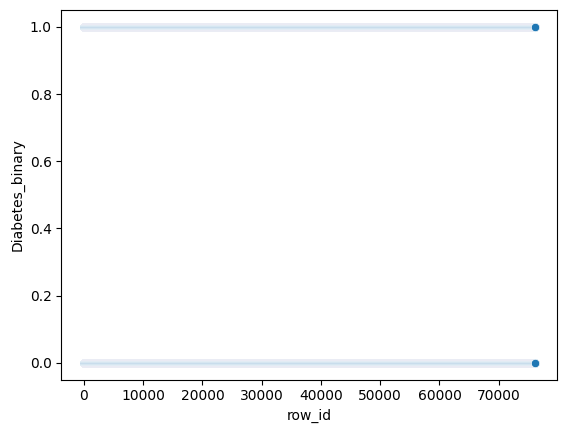

In [18]:
X_test = df2.copy()
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
test_predictions = y_pred
test_data_id = df2.index

# Create the submission dataframe
submission = pd.DataFrame({
    'row_id': test_data_id,
    'Diabetes_binary': test_predictions
})

# Display the first few rows of the submission
display(submission.describe())
sns.scatterplot(data = submission, x = 'row_id', y = 'Diabetes_binary')
plt.show()
plt.close()



# Export to CSV (without the pandas index)
submission.to_csv('hack1.csv', index=False)

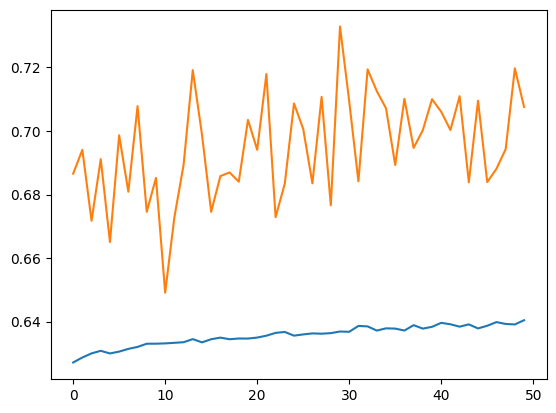

In [19]:
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'test')

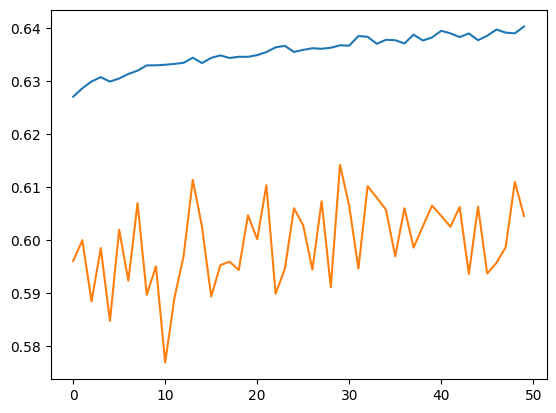

In [20]:
plt.plot(history.history['macro_f1'], label = 'train')
plt.plot(history.history['val_macro_f1'], label = 'test')

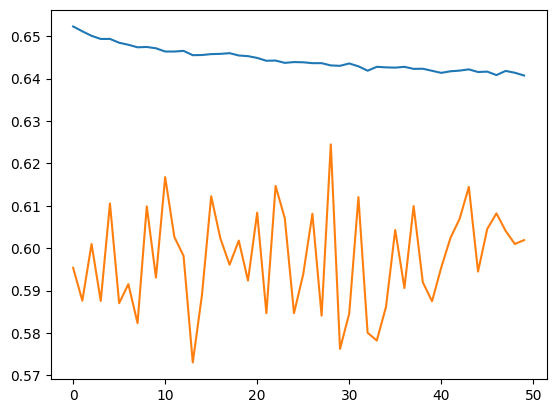

In [21]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')